In [1]:
# libraries: data handling, numeric ops, plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
     

In [2]:
# load the dataset
df=pd.read_csv('Food delivery.csv')

In [3]:
# Quick look at the first rows
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [4]:
# Rows x columns
df.shape

(45593, 20)

In [5]:
# Dtypes + null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [6]:
# Values may be stored as strings even when they look numeric — check the actual type
type(df['Delivery_person_Age'][0])

str

In [7]:
# Note the messy formatting: categories arrive as "conditions Sunny", plus a literal "conditions NaN"
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

### Basic Data Cleaning

In [8]:
df['Weatherconditions']

0             conditions Sunny
1            conditions Stormy
2        conditions Sandstorms
3             conditions Sunny
4            conditions Cloudy
                 ...          
45588         conditions Windy
45589         conditions Windy
45590        conditions Cloudy
45591        conditions Cloudy
45592           conditions Fog
Name: Weatherconditions, Length: 45593, dtype: object

In [9]:
# Test the parsing idea on one value before applying it to the whole column
temp="conditions Fog"

In [10]:
# Keep the word after the space; leave real nulls untouched
temp.split(" ")[1] if pd.notnull(temp) else temp

'Fog'

In [11]:
# Weatherconditions arrives as "conditions Sunny" — keep only the actual word
df['Weatherconditions']=df['Weatherconditions'].apply(lambda temp :temp.split(" ")[1] if pd.notnull(temp) else temp)

In [12]:
df['Weatherconditions']

0             Sunny
1            Stormy
2        Sandstorms
3             Sunny
4            Cloudy
            ...    
45588         Windy
45589         Windy
45590        Cloudy
45591        Cloudy
45592           Fog
Name: Weatherconditions, Length: 45593, dtype: object

In [13]:
# All text (object) columns
df.select_dtypes(include='object').columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='object')

In [14]:
# The literal string is padded with spaces — this is why we strip() before comparing to 'NaN'
' NaN '

' NaN '

In [15]:
# For every text column: remove leading/trailing spaces, and turn the literal
# string 'NaN' (not a real null) into an actual np.nan so pandas treats it as missing
for col in df.select_dtypes(include='object').columns :
  df[col]=df[col].str.strip()
  df[col]=df[col].replace('NaN',np.nan)

In [16]:
# After strip + replace, confirm no literal 'NaN' strings remain in a numeric column
df[df['Delivery_person_Age']=='NaN']

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  object 
 3   Delivery_person_Ratings      43685 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

##### The target column is dirty too.Time_taken(min) is stored as text like "(min) 24" instead of the number 24. A model can only regress on numbers, so we split off the label and cast it to int, while carefully leaving genuine missing values as NaN instead of crashing on them.

In [18]:
# Target column still stored as text, e.g. "(min) 24"
type(df['Time_taken(min)'][0])

str

In [19]:
# Same one-value test for the target's "(min) 24" format
temp='(min) 24'

In [20]:
# Take the number after the space and cast to int
int(temp.split(" ")[1]) if pd.notnull(temp) else temp

24

In [21]:
# Target cleanup: "(min) 24" -> 24 (int). Keep real NaNs as NaN instead of crashing on them
df['Time_taken(min)']=df['Time_taken(min)'].apply(lambda temp :int(temp.split(" ")[1]) if pd.notnull(temp) else temp)

In [22]:
type(df['Time_taken(min)'][0])

numpy.int64

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  object 
 3   Delivery_person_Ratings      43685 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [24]:
# Looks numeric but may be stored as text — worth confirming before we cast
df['multiple_deliveries'].value_counts()

multiple_deliveries
1    28159
0    14095
2     1985
3      361
Name: count, dtype: int64

**Cast the numeric-looking columns to real numbers.** errors='coerce' is the key detail: anything that still cannot be parsed becomes NaN rather than raising an exception, which lets us impute those gaps in a single clean step later on.

In [25]:
# Force genuinely numeric columns to numeric dtype; errors='coerce' turns any
# leftover bad values into NaN instead of raising, so we can impute them next
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries'] :
  df[col]=pd.to_numeric(df[col],errors='coerce')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [27]:
# Summary stats — a quick way to spot impossible values (e.g. a rating > 5)
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


**Sanity-check the ranges.** A delivery rating cannot exceed 5, yet describe() shows values above it. Rather than drop these rows we clip them back to the valid maximum of 5 — a bad rating is still a usable signal, so we keep the row.

In [28]:
# Ratings shouldn't exceed 5 — clip any bad values (e.g. 6.0) back to the valid max
df[df['Delivery_person_Ratings']>5]['Delivery_person_Ratings']

3586     6.0
4714     6.0
5169     6.0
5362     6.0
5651     6.0
6394     6.0
7031     6.0
7681     6.0
9499     6.0
9535     6.0
10100    6.0
10737    6.0
12297    6.0
13257    6.0
13652    6.0
14106    6.0
14907    6.0
14944    6.0
16798    6.0
17145    6.0
17708    6.0
18977    6.0
19382    6.0
20269    6.0
21320    6.0
22416    6.0
23375    6.0
24237    6.0
24918    6.0
25285    6.0
26052    6.0
27221    6.0
27399    6.0
28315    6.0
28974    6.0
29535    6.0
30579    6.0
30943    6.0
31233    6.0
32326    6.0
33533    6.0
34688    6.0
38007    6.0
38020    6.0
38561    6.0
38649    6.0
39699    6.0
40223    6.0
41105    6.0
41969    6.0
42072    6.0
42835    6.0
45332    6.0
Name: Delivery_person_Ratings, dtype: float64

In [29]:
df['Delivery_person_Ratings']=df['Delivery_person_Ratings'].clip(upper=5)

In [30]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.632567,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.331560,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            44977 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

In [32]:
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low       15477
Jam       14143
Medium    10947
High       4425
Name: count, dtype: int64

In [33]:
# The mode = most frequent category; this is the value we'll use to impute missing categoricals
df['Road_traffic_density'].mode()[0]

'Low'

### Imputing the remaining missing values

Two column types need two different strategies:

**Numeric columns** → fill with the median. The median is robust to outliers and skew, so a few extreme values will not drag the fill value around the way the mean would.

**Categorical columns** → fill with the mode (the most frequent category), which is the only sensible "average" for a non-numeric field.

In [34]:
# Numeric columns: fill missing values with the median (robust to outliers/skew)
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries'] :
  df[col]=df[col].fillna(df[col].median())

In [35]:
# Categorical columns: fill missing values with the mode (most frequent category)
for col in ['Weatherconditions','Road_traffic_density','Festival','City']:
  df[col]=df[col].fillna(df[col].mode()[0])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

### EDA

For every feature we ask: what does this look like, and does it actually relate to delivery time?

### Exploratory data analysis

Now the data is clean, we ask of every feature: what does its distribution look like, and does it actually relate to delivery time? For categorical features we compare the mean/median Time_taken(min) across groups; for numeric ones we look at trends.

In [37]:
df['Time_taken(min)'].describe()

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

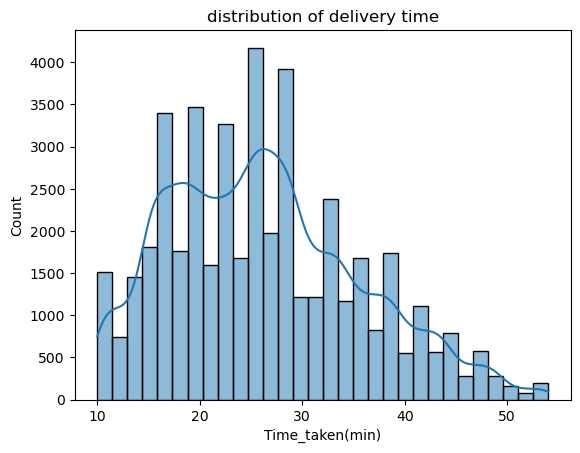

In [38]:
sns.histplot(df['Time_taken(min)'],bins=30,kde =True)
plt.title("distribution of delivery time")
plt.show()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [40]:
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low       16078
Jam       14143
Medium    10947
High       4425
Name: count, dtype: int64

In [41]:
# Does traffic density relate to delivery time? Compare the groups
df.groupby('Road_traffic_density')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Road_traffic_density,,,,
High,4425,27.240000,27.0,8.396012
Jam,14143,31.176624,31.0,9.940904
Low,16078,21.464175,21.0,6.988438
Medium,10947,26.699644,27.0,8.560179


In [42]:
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           8270
Stormy        7586
Cloudy        7536
Sandstorms    7495
Windy         7422
Sunny         7284
Name: count, dtype: int64

In [43]:
# Weather vs delivery time
df.groupby('Weatherconditions')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Weatherconditions,,,,
Cloudy,7536,28.917330,28.0,10.084352
Fog,8270,28.739541,28.0,10.100816
Sandstorms,7495,25.875517,26.0,8.618434
Stormy,7586,25.870815,26.0,8.473273
Sunny,7284,21.856947,20.0,8.327210
Windy,7422,26.118836,26.0,8.615702


In [44]:
df['Festival'].value_counts()

Festival
No     44697
Yes      896
Name: count, dtype: int64

In [45]:
# Festival days — expected to slow deliveries down noticeably
df.groupby('Festival')['Time_taken(min)'].agg(['count','mean','median','std'])

,count,mean,median,std
Festival,,,,
No,44697,25.909256,25.0,9.052291
Yes,896,45.517857,45.0,4.001915


In [46]:
df.groupby('City')['Time_taken(min)'].agg(['count','mean'])

,count,mean
City,,
Metropolitian,35293,27.136486
Semi-Urban,164,49.731707
Urban,10136,22.984017


In [47]:
df.groupby('Type_of_vehicle')['Time_taken(min)'].agg(['count','mean'])

,count,mean
Type_of_vehicle,,
bicycle,68,26.426471
electric_scooter,3814,24.470110
motorcycle,26435,27.605674
scooter,15276,24.480754


In [48]:
df.groupby('Type_of_order')['Time_taken(min)'].agg(['count','mean'])

,count,mean
Type_of_order,,
Buffet,11280,26.283511
Drinks,11322,26.187953
Meal,11458,26.419270
Snack,11533,26.286309


In [49]:
df['Delivery_person_Age'].describe()

count    45593.000000
mean        29.584739
std          5.696333
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

<Axes: xlabel='Delivery_person_Age', ylabel='Count'>

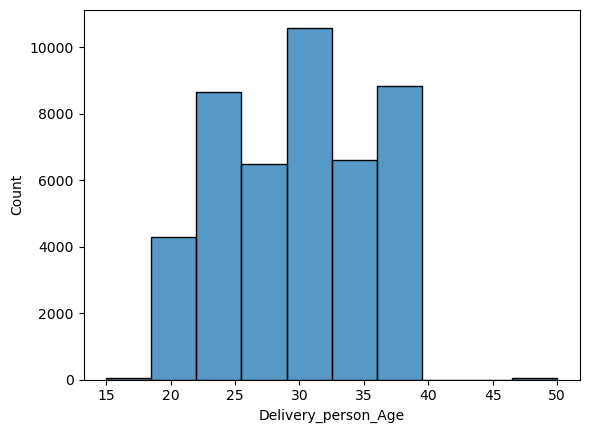

In [50]:
sns.histplot(df['Delivery_person_Age'],bins=10)

In [51]:
# How many riders are over 40? (checking the tail of the age distribution)
df[df['Delivery_person_Age']>40]['Delivery_person_Age'].shape

(53,)

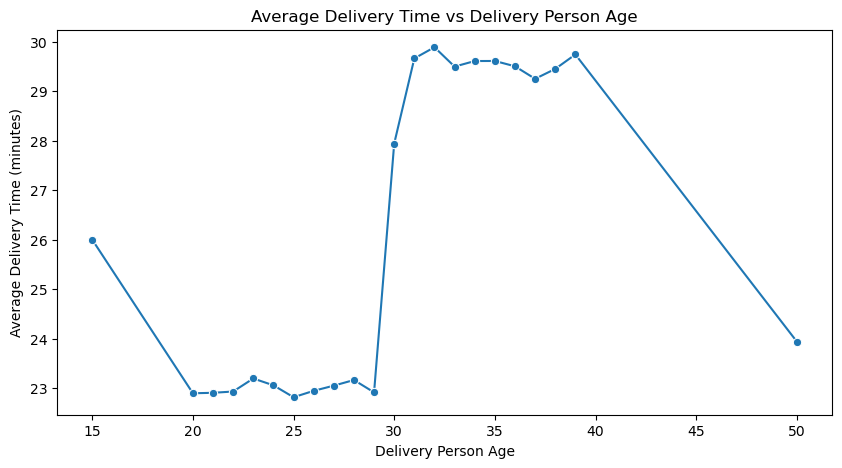

In [52]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Delivery Time vs Delivery Person Age")
plt.xlabel("Delivery Person Age")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

In [53]:
df['Delivery_person_Ratings'].describe()

count    45593.000000
mean         4.635389
std          0.324828
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

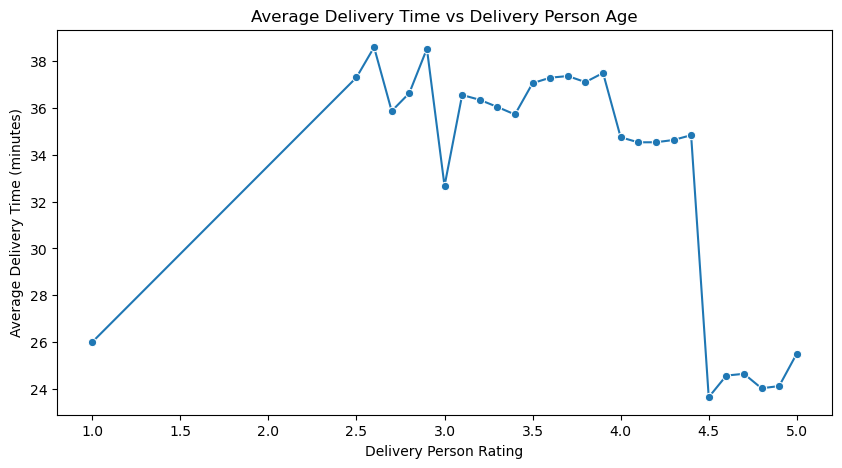

In [54]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=df,
    x='Delivery_person_Ratings',
    y="Time_taken(min)",
    estimator="mean",
    errorbar=None,
    marker="o"
)

plt.title("Average Delivery Time vs Delivery Person Age")
plt.xlabel("Delivery Person Rating")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

In [55]:
# Share of deliveries by low-rated (<4) riders
df[df['Delivery_person_Ratings']<4].shape[0]/len(df)

0.02998267277871603

### Correlation Heatmap (numeric columns so far)

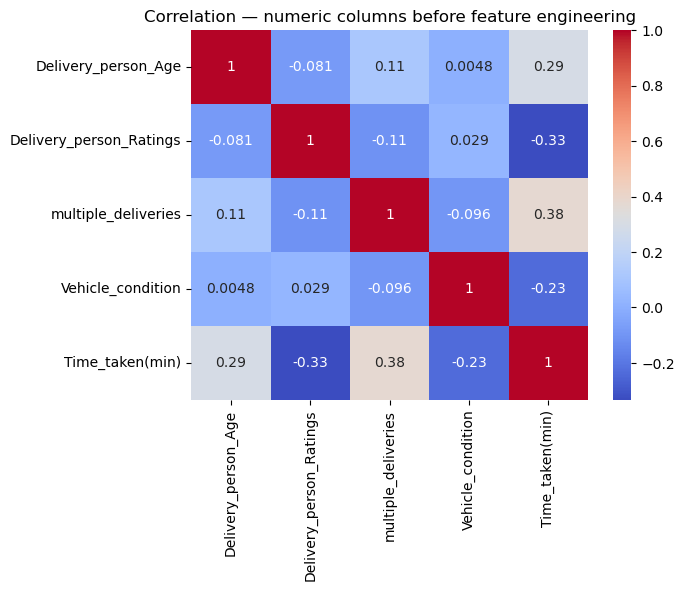

In [56]:
numeric_cols=['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries','Vehicle_condition','Time_taken(min)']
sns.heatmap(df[numeric_cols].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation — numeric columns before feature engineering')
plt.show()

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

### Feature engineering

Raw columns are not always model-ready. Two big opportunities here:

**Location:** we have restaurant and drop-off latitude/longitude — four raw numbers a model cannot use directly. What actually matters is the **distance** between them.

**Time:** the order timestamp hides a useful signal — the **hour of day**, which proxies for lunch/dinner rush.

In [58]:
# Raw date column (stored as text)
df['Order_Date']

0        19-03-2022
1        25-03-2022
2        19-03-2022
3        05-04-2022
4        26-03-2022
            ...    
45588    24-03-2022
45589    16-02-2022
45590    11-03-2022
45591    07-03-2022
45592    02-03-2022
Name: Order_Date, Length: 45593, dtype: object

In [59]:
# Raw order-time column (stored as text) — we'll extract the hour from this
df['Time_Orderd']

0        11:30:00
1        19:45:00
2        08:30:00
3        18:00:00
4        13:30:00
           ...   
45588    11:35:00
45589    19:55:00
45590    23:50:00
45591    13:35:00
45592    17:10:00
Name: Time_Orderd, Length: 45593, dtype: object

In [60]:
# Parse the time and pull out the hour; errors='coerce' turns unparseable times into NaT
hour=pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S', errors='coerce').dt.hour

In [61]:
hour.unique()

array([11., 19.,  8., 18., 13., 21., 17., 20., 14.,  9., 22., 12., 23.,
       nan, 10., 16., 15.,  0.])

In [62]:
# Does the hour of day relate to delivery time? (rush hours should stand out)
df.groupby(hour)['Time_taken(min)'].agg(['mean','median'])

,mean,median
Time_Orderd,,
0.0,22.169767,21.0
8.0,19.584158,19.0
9.0,19.543914,19.0
10.0,19.482170,19.0
11.0,26.380734,27.0
12.0,26.826233,27.0
13.0,27.538265,27.0
14.0,27.537295,27.0
15.0,23.194731,23.0


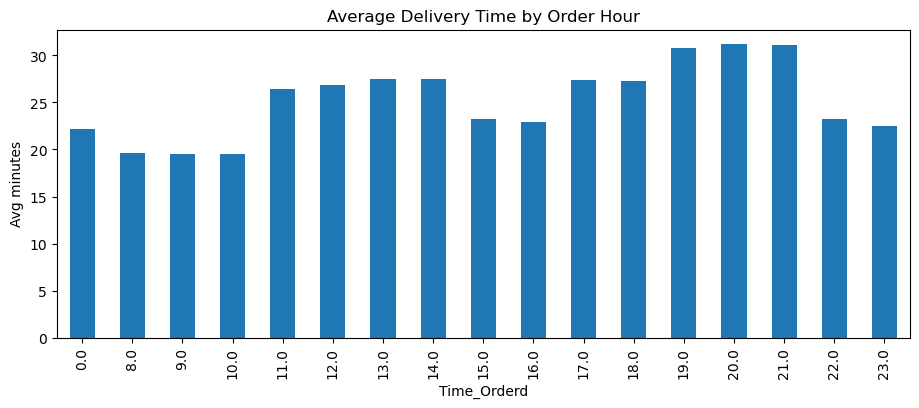

In [63]:
df.groupby(hour)['Time_taken(min)'].mean().plot(kind='bar',figsize=(11,4))
plt.title('Average Delivery Time by Order Hour')
plt.ylabel('Avg minutes')
plt.show()

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

### Distance from coordinates — the Haversine formula

Four raw lat/long columns are collapsed into one strong feature: the great-circle (straight-line over a sphere) distance between the restaurant and the customer.

$$
a = \sin^2\left(\frac{\Delta\phi}{2}\right)
+ \cos\phi_1\cos\phi_2\sin^2\left(\frac{\Delta\lambda}{2}\right)
$$

$$
d = 2r\arcsin\left(\sqrt{a}\right)
$$

where $\phi$ is latitude and $\lambda$ is longitude (in **radians**), $\Delta$ is the difference between the two points, and $r \approx 6371\ km$ is Earth's radius. The result, `distance_km`, is one of the most predictive features in the whole dataset.

In [65]:
def calculate_series_distance(
    lat1_series, lon1_series, lat2_series, lon2_series, miles=False
):
    """Calculates the great-circle (straight-line) distance between two series of

    lat/lon points using the Haversine formula. Returns distance in km (or
    miles). Turns four raw coordinate columns into one meaningful 'distance'
    feature.
    """
    r = 3956 if miles else 6371
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1_series, lon1_series, lat2_series, lon2_series]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return c * r

In [66]:
df['distance_km']=calculate_series_distance(df['Restaurant_latitude'],df['Restaurant_longitude'],df['Delivery_location_latitude'],df['Delivery_location_longitude'])

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [68]:
df['distance_km'].describe()

count    45593.000000
mean        99.303911
std       1099.731281
min          1.465067
25%          4.663493
50%          9.264281
75%         13.763977
max      19692.674606
Name: distance_km, dtype: float64

**Outlier check.** Some `distance_km` values are physically absurd (hundreds or thousands of km) — the tell-tale sign of corrupt `0,0` or swapped coordinates. We keep only realistic intra-city trips (`< 100 km`) so these bad rows do not distort the model.

In [69]:
# The >100 km rows: inspect the extreme distances (likely corrupt coordinates)
df[df['distance_km']>100]['distance_km'].describe()

count      431.000000
mean      9484.671093
std       6252.618252
min       2216.065794
25%       4434.856783
50%       5897.015762
75%      17132.390571
max      19692.674606
Name: distance_km, dtype: float64

In [70]:
# The realistic (<100 km) trips: this is the range we'll keep
df[df['distance_km']<100]['distance_km'].describe()

count    45162.000000
mean         9.735396
std          5.608508
min          1.465067
25%          4.663412
50%          9.220209
75%         13.681490
max         20.969489
Name: distance_km, dtype: float64

In [71]:
df[df['distance_km']>100]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km
92,0xc042,AGRRES010DEL01,34.0,4.7,-27.163303,78.057044,27.233303,78.127044,16-02-2022,23:00:00,...,Sandstorms,Low,1,Drinks,scooter,0.0,No,Metropolitian,15,6048.631240
283,0xc044,AGRRES12DEL03,32.0,4.7,-27.165108,78.015053,27.225108,78.075053,13-02-2022,20:55:00,...,Sandstorms,Jam,2,Meal,scooter,1.0,No,Metropolitian,31,6047.919478
289,0x4db,PUNERES02DEL03,30.0,4.7,-18.551440,-73.804855,18.611440,73.864855,05-03-2022,NaN,...,Stormy,Jam,2,Meal,scooter,0.0,No,Urban,12,16612.239055
425,0xc003,DEHRES13DEL02,30.0,4.7,-30.366322,-78.070453,30.496322,78.200453,18-02-2022,NaN,...,Fog,Low,3,Snack,scooter,1.0,No,Metropolitian,20,17744.205087
534,0x473,MYSRES07DEL03,30.0,4.7,-12.325461,-76.632278,12.385461,76.692278,03-03-2022,NaN,...,Fog,Low,3,Buffet,scooter,1.0,No,Metropolitian,16,17118.828366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44933,0xc0c2,AURGRES03DEL03,30.0,4.9,-19.874733,75.353942,19.904733,75.383942,15-02-2022,22:20:00,...,Fog,Low,1,Buffet,motorcycle,0.0,No,Metropolitian,15,4423.276011
45020,0x56b,PUNERES04DEL01,30.0,4.7,-18.514210,73.838429,18.524210,73.848429,21-03-2022,NaN,...,Fog,Low,3,Drinks,electric_scooter,1.0,No,Metropolitian,30,4118.484540
45108,0xc01b,GOARES18DEL01,30.0,4.7,-15.493950,-73.827423,15.563950,73.897423,16-02-2022,NaN,...,Windy,Jam,2,Meal,scooter,1.0,No,Urban,19,16560.629487
45182,0xc0c7,KNPRES16DEL02,30.0,4.0,-26.482581,80.315628,26.532581,80.365628,17-02-2022,22:25:00,...,Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Metropolitian,34,5895.019482


In [72]:
df=df[df['distance_km']<100].reset_index(drop=True)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45162 non-null  object 
 1   Delivery_person_ID           45162 non-null  object 
 2   Delivery_person_Age          45162 non-null  float64
 3   Delivery_person_Ratings      45162 non-null  float64
 4   Restaurant_latitude          45162 non-null  float64
 5   Restaurant_longitude         45162 non-null  float64
 6   Delivery_location_latitude   45162 non-null  float64
 7   Delivery_location_longitude  45162 non-null  float64
 8   Order_Date                   45162 non-null  object 
 9   Time_Orderd                  43706 non-null  object 
 10  Time_Order_picked            45162 non-null  object 
 11  Weatherconditions            45162 non-null  object 
 12  Road_traffic_density         45162 non-null  object 
 13  Vehicle_conditio

In [74]:
df[df['distance_km']>100]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km


In [75]:
# Hour of day the order was placed (0-23) — kept continuous, not binned (see note below)
df['order_hour']=pd.to_datetime(df['Time_Orderd'],format='%H:%M:%S', errors='coerce').dt.hour

In [76]:
# A handful of unparseable timestamps become NaN hours — fill with the median hour
df['order_hour']=df['order_hour'].fillna(df['order_hour'].median())

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45162 entries, 0 to 45161
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45162 non-null  object 
 1   Delivery_person_ID           45162 non-null  object 
 2   Delivery_person_Age          45162 non-null  float64
 3   Delivery_person_Ratings      45162 non-null  float64
 4   Restaurant_latitude          45162 non-null  float64
 5   Restaurant_longitude         45162 non-null  float64
 6   Delivery_location_latitude   45162 non-null  float64
 7   Delivery_location_longitude  45162 non-null  float64
 8   Order_Date                   45162 non-null  object 
 9   Time_Orderd                  43706 non-null  object 
 10  Time_Order_picked            45162 non-null  object 
 11  Weatherconditions            45162 non-null  object 
 12  Road_traffic_density         45162 non-null  object 
 13  Vehicle_conditio

In [78]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,order_hour
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,...,High,2,Snack,motorcycle,0.0,No,Urban,24,3.025149,11.0
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,...,Jam,2,Snack,scooter,1.0,No,Metropolitian,33,20.183530,19.0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,...,Low,0,Drinks,motorcycle,1.0,No,Urban,26,1.552758,8.0
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,...,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,18.0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,...,High,1,Snack,scooter,1.0,No,Metropolitian,30,6.210138,13.0


In [79]:
# Too many unique delivery-person IDs to one-hot encode — so we won't use the ID as a feature
len(df['Delivery_person_ID'].unique())

1320

### Assemble the feature matrix X and target y

We pick the columns that carry real predictive signal. Note what we drop: the raw lat/long (now summarised by `distance_km`), the raw timestamps (now `order_hour`), and identifiers like `Delivery_person_ID` — an ID is a label, not a feature, and one-hot encoding thousands of unique IDs would just invite overfitting.

In [80]:
features=['Delivery_person_Age','Delivery_person_Ratings','distance_km','order_hour','Weatherconditions','Road_traffic_density',
          'Vehicle_condition','Type_of_order','Type_of_vehicle','multiple_deliveries','Festival','City']

In [81]:
X=df[features]

In [82]:
y=df['Time_taken(min)']

###  Encoding categorical variables

Categorical features come in two flavours, and each needs different treatment:

- **Ordinal (has a natural order):** `Road_traffic_density` runs Low < Medium < High < Jam. We map it to `0, 1, 2, 3` so the model can learn a single `more traffic → more time` trend.
- **Nominal (no order):** weather, city, vehicle type, order type. These get **one-hot encoded** into 0/1 columns. `drop_first=True` removes one redundant column per feature to avoid the *dummy-variable trap* (perfect multicollinearity).

In [83]:
# Traffic density has a real order (Low < Medium < High < Jam) -> ordinal encode instead of one-hot,
# so the model can learn a single, sensible increasing relationship
traffic_mapping={
    'Low':0,
    'Medium': 1,
    'High' : 2,
    'Jam' : 3
}

X['Road_traffic_density']=X['Road_traffic_density'].map(traffic_mapping)

C:\Users\rahul\AppData\Local\Temp\ipykernel_11304\2671883894.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Road_traffic_density']=X['Road_traffic_density'].map(traffic_mapping)


In [84]:
X['Road_traffic_density']

0        2
1        3
2        0
3        1
4        2
        ..
45157    2
45158    3
45159    0
45160    2
45161    1
Name: Road_traffic_density, Length: 45162, dtype: int64

In [85]:
X['Weatherconditions'].value_counts()

Weatherconditions
Fog           8071
Stormy        7544
Cloudy        7485
Sandstorms    7442
Windy         7382
Sunny         7238
Name: count, dtype: int64

In [86]:
X=pd.get_dummies(X,columns=['Type_of_order','Type_of_vehicle','Festival','City','Weatherconditions'],drop_first=True,dtype=int)

### Train / test split

We hold out **20%** of the data that the model never sees during training. Evaluating on this untouched set is the only honest way to estimate how the model will perform on **new, real orders**. `random_state=42` makes the split reproducible.

### Train/test split

Hold out 20% of the data the model never trains on, so we can honestly check how well it generalizes.

In [87]:
from sklearn.model_selection import train_test_split

In [88]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [89]:
# Confirm the split sizes (~80% train / ~20% test)
X_train.shape,X_test.shape

((36129, 21), (9033, 21))

### Feature scaling (standardization)

Each feature is rescaled to mean 0 and standard deviation 1:

$$
z = \frac{x-\mu}{\sigma}
$$

This matters for **Linear Regression**, whose coefficients otherwise get distorted by features on wildly different scales (e.g. `distance_km` vs a 0/1 dummy). Tree-based models (Decision Tree, Random Forest, XGBoost) are scale-invariant and do not need it — but scaling does them no harm, so we apply one consistent transform for every model.

**Critical:** the scaler is fit on the training set only, then *applied* to the test set. Fitting on the test set would leak information about the held-out data and inflate our scores.

### Feature scaling

Standardize all features to mean 0 / std 1. Needed for Linear Regression (distance-based math); tree-based models don't need it, but scaling doesn't hurt them either, so we apply it once for all models.

In [90]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()

In [91]:
# Fit the scaler on TRAIN ONLY, then apply it to both — never fit on test data
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [92]:
# Note: scaling returns a plain numpy array — column names and index are lost here
X_train_scaled

array([[-1.33517305,  0.51156709, -0.35171278, ..., -0.44643354,
        -0.43645196,  2.26789395],
       [ 1.12628719,  0.19877778,  1.34683601, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [-0.80771728, -0.42680083,  1.30714108, ...,  2.23997508,
        -0.43645196, -0.44093773],
       ...,
       [ 1.65374296, -0.11401152, -0.67284161, ..., -0.44643354,
        -0.43645196,  2.26789395],
       [ 0.77465001,  0.51156709, -1.18141457, ..., -0.44643354,
        -0.43645196, -0.44093773],
       [ 0.77465001, -1.36516875,  0.65355565, ..., -0.44643354,
        -0.43645196, -0.44093773]], shape=(36129, 21))

In [93]:
# Put back into DataFrames with the original column names/index for readability
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [94]:
import joblib
# Save the fitted scaler
joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']

### Model 1 — Linear Regression (baseline)

Simplest possible model: fits one straight-line relationship across all features. Fast and interpretable

In [95]:
from sklearn.linear_model import LinearRegression

In [96]:
lr=LinearRegression()

In [97]:
lr.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### The linear model

Linear regression predicts with one weight per feature plus an intercept:

$$
\hat{y} = w_0 + w_1x_1 + w_2x_2 + \cdots + w_px_p
$$

Training finds the weights $w$ that minimise the sum of squared errors. It is fast and fully interpretable — the perfect **baseline** for the tree models to beat.

In [98]:
# One coefficient per feature (in the scaled space) — larger magnitude = bigger influence
lr.coef_

array([ 2.25707747, -2.17742371,  2.08640083, -0.54457378,  2.92036387,
       -1.7354634 ,  1.71928013, -0.07066725, -0.02591592, -0.01696524,
       -0.4410398 , -0.97325398, -1.21548077,  1.33110365,  0.58436762,
       -0.80964671,  0.08306582, -1.00542433, -1.01075931, -2.31276779,
       -0.96904815])

In [99]:
# Line the coefficients up with their feature names to read off which features matter most
X_train.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
       'order_hour', 'Road_traffic_density', 'Vehicle_condition',
       'multiple_deliveries', 'Type_of_order_Drinks', 'Type_of_order_Meal',
       'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter',
       'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter', 'Festival_Yes',
       'City_Semi-Urban', 'City_Urban', 'Weatherconditions_Fog',
       'Weatherconditions_Sandstorms', 'Weatherconditions_Stormy',
       'Weatherconditions_Sunny', 'Weatherconditions_Windy'],
      dtype='object')

# How we evaluate: RMSE and R²

**Root Mean Squared Error** — average prediction error, in the target's own units (minutes):

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
$$

So "RMSE ≈ 4" means predictions are off by roughly 4 minutes on average. Lower is better.

**R² (coefficient of determination)** — the fraction of the variance in delivery time the model explains:

$$
R^2 = 1-\frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}
$$

$R^2 = 1$ is perfect; $R^2 = 0$ is no better than always guessing the mean. We compute both metrics on **train and test** — a large gap (great on train, poor on test) is the signature of **overfitting**.

In [100]:
from sklearn.metrics import r2_score,mean_squared_error

In [101]:
# Predictions on the held-out test set
y_pred_test=lr.predict(X_test_scaled)

In [102]:
# Test RMSE (average error in minutes)
rmse_test=np.sqrt(mean_squared_error(y_test,y_pred_test))

In [103]:
# Train RMSE — compare with test RMSE to check for overfitting
rmse_train=np.sqrt(mean_squared_error(y_train,lr.predict(X_train_scaled)))

In [104]:
r2_test=r2_score(y_test,y_pred_test)

In [105]:
r2_train=r2_score(y_train,lr.predict(X_train_scaled))

In [106]:
# Train: RMSE, R²
print(rmse_train,r2_train)

6.043532429197743 0.5833426978406997


In [107]:
# Test: RMSE, R²  — close to train, so the linear model underfits rather than overfits
print(rmse_test,r2_test)

6.212510956097219 0.5693154667609591


### Model 2 — Decision Tree

Splits the data with a series of yes/no questions on features ("is traffic Jam?", "is distance > 5km?") to separate slow orders from fast ones. Powerful, but an unconstrained tree will memorize the training data.

In [108]:
from sklearn.tree import DecisionTreeRegressor

In [109]:
dt=DecisionTreeRegressor(random_state=42)

In [110]:
dt.fit(X_train_scaled,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [111]:
y_pred_dt=dt.predict(X_test_scaled)

In [112]:
# Test performance
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,dt.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,dt.predict(X_test_scaled))
print("dt rmse",rmse)
print("dt r2",r2)

dt rmse 5.463261556519014
dt r2 0.6669350543728361


In [113]:
# Now check TRAIN performance for comparison — this is how we catch overfitting
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_train,dt.predict(X_train_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_train,dt.predict(X_train_scaled))
print("dt train rmse",rmse)
print("dt train r2",r2)

dt train rmse 0.0
dt train r2 1.0


### Model 3 — Random Forest

Hundreds of decision trees, each trained on a random subset of rows and features, with predictions averaged. Individual trees' errors tend to cancel out, which is why forests overfit far less than a single deep tree.

In [114]:
from sklearn.ensemble import RandomForestRegressor

In [115]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)

In [116]:
rf.fit(X_train_scaled,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [117]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,rf.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,rf.predict(X_test_scaled))
print("rf rmse",rmse)
print("rf r2",r2)

rf rmse 4.028540060127521
rf r2 0.8188992229800744


In [118]:
#train data
mse=mean_squared_error(y_train,rf.predict(X_train_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_train,rf.predict(X_train_scaled))
print("rf rmse",rmse)
print("rf r2",r2)

rf rmse 1.5065961890052253
rf r2 0.9741064847794211


### Hyperparameter tuning with RandomizedSearchCV

A full grid search over tree count × depth × leaf size × feature fraction is combinatorially huge. RandomizedSearchCV instead samples a fixed number of random combinations and cross-validates each — far cheaper, and in practice it lands very close to the grid-search optimum. (Left commented out so the notebook re-runs quickly; uncomment to reproduce.)

**Tuning:** randomized search over tree count/depth/features — cheaper than a full grid search over this many hyperparameters.

In [119]:
# from sklearn.model_selection import RandomizedSearchCV

# rf_param_dist={
#     'n_estimators':[200,300,400,500],
#     'max_depth':[10,15,20,25,None],
#     'min_samples_leaf':[1,2,4],
#     'min_samples_split':[2,5,10],
#     'max_features':['sqrt','log2',0.5]
# }
# # Sample 25 random combinations instead of testing every combination exhaustively
# rf_search=RandomizedSearchCV(RandomForestRegressor(random_state=42),rf_param_dist,n_iter=25,cv=3,scoring='r2',random_state=42,n_jobs=-1)
# rf_search.fit(X_train_scaled,y_train)
# print("best params",rf_search.best_params_)
# rf_best=rf_search.best_estimator_

In [120]:
# r2_rf_tuned=r2_score(y_test,rf_best.predict(X_test_scaled))
# rmse_rf_tuned=np.sqrt(mean_squared_error(y_test,rf_best.predict(X_test_scaled)))
# print("tuned rf rmse",rmse_rf_tuned)
# print("tuned rf r2",r2_rf_tuned)

In [121]:
# Which features the forest actually leans on
# rf.feature_importances_

In [122]:
# Feature order (useful for interpreting coefficients / importances)
X_train.columns

Index(['Delivery_person_Age', 'Delivery_person_Ratings', 'distance_km',
       'order_hour', 'Road_traffic_density', 'Vehicle_condition',
       'multiple_deliveries', 'Type_of_order_Drinks', 'Type_of_order_Meal',
       'Type_of_order_Snack', 'Type_of_vehicle_electric_scooter',
       'Type_of_vehicle_motorcycle', 'Type_of_vehicle_scooter', 'Festival_Yes',
       'City_Semi-Urban', 'City_Urban', 'Weatherconditions_Fog',
       'Weatherconditions_Sandstorms', 'Weatherconditions_Stormy',
       'Weatherconditions_Sunny', 'Weatherconditions_Windy'],
      dtype='object')

### Model 4 — XGBoost

Trees trained sequentially — each new tree specifically corrects the errors of all trees before it (gradient boosting). Usually the strongest single model for structured/tabular data like ours.

In [124]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   - -------------------------------------- 2.1/48.9 MB 9.7 MB/s eta 0:00:05
   --- ------------------------------------ 4.2/48.9 MB 10.1 MB/s eta 0:00:05
   ----- ---------------------------------- 6.6/48.9 MB 10.1 MB/s eta 0:00:05
   ------- -------------------------------- 8.9/48.9 MB 10.2 MB/s eta 0:00:04
   --------- ------------------------------ 11.3/48.9 MB 10.4 MB/s eta 0:00:04
   ---------- ----------------------------- 13.4/48.9 MB 10.2 MB/s eta 0:00:04
   ------------ --------------------------- 15.5/48.9 MB 10.3 MB/s eta 0:00:04
   -------------- ------------------------- 17.3/48.9 MB 10.0 MB/s eta 0:00:04
   ---------------- ----------------------- 19.7/48.9 MB 10.1 MB/s eta 0:00:03
   ----------------- ---------------------- 22.0/48.9 MB 10.2 MB/s eta 0:00:

In [125]:
from xgboost import XGBRegressor

In [126]:
xgb=XGBRegressor(n_estimators=100,random_state=42)

In [127]:
xgb.fit(X_train_scaled,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [128]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,xgb.predict(X_test_scaled))
rmse=np.sqrt(mse)
r2=r2_score(y_test,xgb.predict(X_test_scaled))
print("xgb rmse",rmse)
print("xgb r2",r2)

xgb rmse 3.9989541593892377
xgb r2 0.8215494751930237


In [130]:
from sklearn.model_selection import RandomizedSearchCV

In [131]:
xgb_param_dist={
    'n_estimators':[300,500,800],
    'max_depth':[3,4,5,6,8],
    'learning_rate':[0.01,0.03,0.05,0.1],
    'subsample':[0.7,0.8,0.9,1.0],
    'colsample_bytree':[0.7,0.8,0.9,1.0],
    'reg_alpha':[0,0.1,0.5,1],
    'reg_lambda':[1,1.5,2]
}
xgb_search=RandomizedSearchCV(XGBRegressor(random_state=42),xgb_param_dist,n_iter=40,cv=3,scoring='r2',random_state=42,n_jobs=-1)
xgb_search.fit(X_train_scaled,y_train)
print("best params",xgb_search.best_params_)
xgb_best=xgb_search.best_estimator_

best params {'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [132]:
r2_xgb_train=r2_score(y_train,xgb_best.predict(X_train_scaled))
rmse_xgb_train=np.sqrt(mean_squared_error(y_train,xgb_best.predict(X_train_scaled)))
print("xgb train rmse",rmse_xgb_train)
print("xgb train r2",r2_xgb_train)

xgb train rmse 3.678752934373365
xgb train r2 0.8456173539161682


In [133]:
r2_xgb_test=r2_score(y_test,xgb_best.predict(X_test_scaled))
rmse_xgb_test=np.sqrt(mean_squared_error(y_test,xgb_best.predict(X_test_scaled)))
print("xgb rmse",rmse_xgb_test)
print("xgb r2",r2_xgb_test)

xgb rmse 3.9102103946988
xgb r2 0.8293818831443787


In [134]:
# Number of features p — needed for the adjusted R² formula below
X_test_scaled.shape[1]

21

### Adjusted R² — a fairer score when comparing feature sets

Plain $R^2$ has a flaw: it **never decreases** when you add a feature, even a useless one. That makes it useless for deciding whether a *new* feature actually earns its place. Adjusted $R^2$ fixes this by penalising the number of features $p$:

$$
R^2_{\text{adj}} = 1 - (1-R^2)\frac{n-1}{n-p-1}
$$

where $n$ is the number of samples and $p$ the number of features. It only rises if a new feature helps **more** than the complexity it adds — exactly the yardstick we need for the experiment in the next section.

In [135]:
# Test Adjusted R²
y_test_pred = xgb_best.predict(X_test_scaled)

n_test = len(y_test)
p_test = X_test_scaled.shape[1]

adj_r2_xgb_test = 1 - (1 - r2_xgb_test) * (n_test - 1) / (n_test - p_test - 1)

print("xgb test adjusted r2", adj_r2_xgb_test)

xgb test adjusted r2 0.8289842601886614


# Feature experiment: does "order period" help?

Hypothesis: delivery time spikes during meal rushes, so bucketing `order_hour` into **Lunch / Dinner / Normal** might add signal beyond the raw hour.

We test this honestly:

1. Build the new feature on the **unscaled** train/test data (so the buckets are correct).
2. One-hot encode it and fit a **fresh** scaler on train only.
3. Retrain our strongest model with the **same tuned hyperparameters**, changing only the feature set — a fair, controlled comparison.

We then read **Adjusted R²** (from above) to judge whether the extra feature was worth it.

In [136]:
# Recall: X_train is the UNSCALED training features — we build the new feature here first
X_train

,Delivery_person_Age,Delivery_person_Ratings,distance_km,order_hour,Road_traffic_density,Vehicle_condition,multiple_deliveries,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,...,Type_of_vehicle_motorcycle,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy
24844,22.0,4.8,7.762944,17.0,1,2,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
33010,36.0,4.7,17.297866,21.0,3,2,2.0,1,0,0,...,0,1,1,0,0,0,0,0,0,0
16599,25.0,4.5,17.075035,21.0,3,2,0.0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
35248,38.0,4.8,3.040816,11.0,2,1,0.0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
14293,26.0,5.0,3.145067,8.0,0,0,1.0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,38.0,4.9,4.657592,21.0,3,0,1.0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
44732,30.0,4.7,20.181187,23.0,0,0,0.0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
38158,39.0,4.6,5.960265,13.0,2,2,1.0,1,0,0,...,1,0,0,0,0,0,0,0,0,1
860,34.0,4.8,3.105356,8.0,0,1,1.0,0,0,1,...,0,1,0,0,0,1,0,0,0,0


In [137]:
# Bucket the order hour into meal periods (lunch / dinner rushes vs the rest)
def order_period(hour):
  if 12<=hour<=14 :
    return "Lunch"
  elif 19<=hour<=21 :
    return "Dinner"
  else :
    return "Normal"

In [138]:
# 1. Copy unscaled data
X_train_exp = X_train.copy()
X_test_exp = X_test.copy()

In [139]:
# 2. Create the new feature BEFORE scaling
X_train_exp['order_period'] = X_train_exp['order_hour'].apply(order_period)
X_test_exp['order_period'] = X_test_exp['order_hour'].apply(order_period)

In [140]:
# Confirm the new order_period column landed correctly
X_train_exp

,Delivery_person_Age,Delivery_person_Ratings,distance_km,order_hour,Road_traffic_density,Vehicle_condition,multiple_deliveries,Type_of_order_Drinks,Type_of_order_Meal,Type_of_order_Snack,...,Type_of_vehicle_scooter,Festival_Yes,City_Semi-Urban,City_Urban,Weatherconditions_Fog,Weatherconditions_Sandstorms,Weatherconditions_Stormy,Weatherconditions_Sunny,Weatherconditions_Windy,order_period
24844,22.0,4.8,7.762944,17.0,1,2,1.0,0,0,0,...,0,0,0,0,0,0,0,0,1,Normal
33010,36.0,4.7,17.297866,21.0,3,2,2.0,1,0,0,...,1,1,0,0,0,0,0,0,0,Dinner
16599,25.0,4.5,17.075035,21.0,3,2,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,Dinner
35248,38.0,4.8,3.040816,11.0,2,1,0.0,0,1,0,...,1,0,0,0,0,0,1,0,0,Normal
14293,26.0,5.0,3.145067,8.0,0,0,1.0,0,0,0,...,0,0,0,0,1,0,0,0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,38.0,4.9,4.657592,21.0,3,0,1.0,0,0,1,...,0,0,0,0,0,0,0,0,1,Dinner
44732,30.0,4.7,20.181187,23.0,0,0,0.0,0,0,1,...,0,0,0,0,0,0,0,0,1,Normal
38158,39.0,4.6,5.960265,13.0,2,2,1.0,1,0,0,...,0,0,0,0,0,0,0,0,1,Lunch
860,34.0,4.8,3.105356,8.0,0,1,1.0,0,0,1,...,1,0,0,0,1,0,0,0,0,Normal


In [141]:
# 3. One-hot encode
X_train_exp = pd.get_dummies(
    X_train_exp, columns=['order_period'], drop_first=True, dtype=int
)

X_test_exp = pd.get_dummies(
    X_test_exp, columns=['order_period'], drop_first=True, dtype=int
)


In [142]:
# 4. Create a NEW scaler and fit ONLY on expanded training data
scaler_exp = StandardScaler()

X_train_exp_scaled = scaler_exp.fit_transform(X_train_exp)
X_test_exp_scaled = scaler_exp.transform(X_test_exp)

In [143]:
# Retrain our strongest model (same tuned hyperparameters) WITH the new feature, for a fair comparison
xgb_with_period = XGBRegressor(**xgb_search.best_params_, random_state=42)
xgb_with_period.fit(X_train_exp_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [144]:
n_test = X_test_exp.shape[0]
p_test = X_test_exp.shape[1]
r2_with_period_test = r2_score(y_test, xgb_with_period.predict(X_test_exp_scaled))
adj_r2_test = 1 - (1 - r2_with_period_test) * (n_test - 1) / (n_test - p_test - 1)
print("Test Adjusted R²:", adj_r2_test)

Test Adjusted R²: 0.8290139991285164


# Results & model persistence

XGBoost (tuned) is our best model. Below we save both the fitted **model** and the **scaler** with `joblib`, then reload them and run a few sample predictions — the same two-step (`scaler.transform` → `model.predict`) any production service would use.

| Model | Test R² | Test RMSE (min) | Train R² | Verdict |
|---|---:|---:|---:|---|
| Linear Regression | 0.57 | 6.21 | 0.58 | underfits — relationships aren't linear |
| Decision Tree | 0.67 | 5.46 | **1.00** | memorises train set (train RMSE = 0) |
| Random Forest | 0.82 | 4.03 | 0.97 | big gain: averaging tames overfitting |
| **XGBoost (tuned)** | **0.83** | **3.91** | 0.85 | best score *and* healthiest train/test gap |

The `order_period` experiment left Adjusted R² essentially unchanged (~0.829), so we keep the simpler model — a useful reminder that not every engineered feature earns its keep.

In [145]:
joblib.dump(xgb_best, "xgb_best.pkl")

['xgb_best.pkl']

In [147]:
model = joblib.load("xgb_best.pkl")
scaler = joblib.load("standard_scaler.pkl")

In [148]:
# Grab 3 raw (unscaled) test rows to mimic new incoming orders
sample=X_test[0:3]

In [150]:
# Apply the SAME scaler the model was trained with
sample_scaled=scaler.transform(sample)

In [151]:
# Predict delivery time (minutes) for the 3 samples
predictions=model.predict(sample_scaled)

In [152]:
# Model's predicted minutes
predictions

array([40.904934, 19.128914, 38.713867], dtype=float32)

In [153]:
# Actual minutes — compare against the predictions above
y_test[0:3].values

array([46, 19, 40])